# 3 Predictive Analytics with a) Support Vector Machines and b) Neural Networks

Following the descriptive analysis in Section 2, this section constructs two supervised models that predict taxi trip demand in spatio-temporal resolution, that is, for each spatial unit and time bucket. The objective is not to forecast bucket x+1 from bucket x, but to estimate demand conditional on calendar and environmental context, for example, "what demand can be expected on a rainy Sunday from 10-11 am around the outskirts of the city?" Features are therefore restricted to calendar, weather, and spatial identity. The lagged demand of the immediately preceding bucket is deliberately excluded. The canonical modeling dataset is the H3 r6 x 4h aggregation, zero-filled as established in Task 1.

The section is organised as a shared modeling foundation followed by the two model families and a comparative synthesis. Feature design and the validation strategy (3.1-3.2) are fixed first, since the resulting feature matrix, data splits, and evaluation metrics (MAE, RMSE, R2) are reused by every subsequent subsection to keep results comparable. The two model families are then developed independently against this common interface. Support vector machines are covered in 3.3-3.4, and a feedforward neural network in 3.5-3.6. Resolution sensitivity (3.7) and the holdout comparison (3.8) consume the trained models and are therefore placed last.

### 3.1 Modeling dataset and feature design

The aggregated panel is reframed as a supervised regression problem with target `demand_count` and feature matrix `X = [calendar, weather, spatial identity]`. Required outputs:

- Definition of the target `demand_count` and confirmation of the zero-filled structure (every cell x bucket present).
- Calendar features derived from `timestamp`: time-of-day bucket, day-of-week, weekend indicator, month/season. Cyclical (sin/cos) encodings are applied where continuity matters (23:00 -> 00:00).
- Weather features as already present in the dataset (`temp_4h`, `rain_4h`, `snow_4h`, `precip_4h`, `wind_speed_4h`, `weather_code_4h`).
- A spatial encoding of each H3 cell. The choice between cell-centroid latitude/longitude (continuous, permitting spatial interpolation) and one-hot encoding (high cardinality) is documented and justified.
- A clean feature matrix and target reused by all downstream subsections. To avoid leakage, lagged or same-bucket demand of the target is not included.

In [5]:
import pathlib
import numpy as np
import pandas as pd

PROCESSED = pathlib.Path("../processed")

# Canonical modeling dataset from Task 1: H3 r6 x 4h, zero-filled, weather-enriched.
# One row per hexagon x 4-hour bucket. This is the base for 3.1 feature design.
df = pd.read_parquet(PROCESSED / "df_agg_r6_4h.parquet")

# quick look
print("shape:", df.shape)
print("cells:", df["location_id"].nunique(),
      "| time buckets:", df["timestamp"].nunique())
print("date range:", df["timestamp"].min(), "->", df["timestamp"].max())
print("rows == cells x buckets (fully zero-filled)?",
      df.shape[0] == df["location_id"].nunique() * df["timestamp"].nunique())
print("\ncolumns / dtypes:")
print(df.dtypes)
print("\nmissing values per column:")
print(df.isna().sum())
print("\ndemand_count summary:")
print(df["demand_count"].describe())

df.head(10)

shape: (133029, 15)
cells: 27 | time buckets: 4927
date range: 2024-01-01 00:00:00 -> 2026-04-01 00:00:00
rows == cells x buckets (fully zero-filled)? True

columns / dtypes:
location_id                       str
timestamp              datetime64[us]
demand_count                    int64
avg_trip_miles                Float32
avg_trip_seconds              Float64
avg_trip_total                Float32
n_unique_taxis                float64
spatial_resolution                str
temporal_resolution               str
temp_4h                       float64
rain_4h                       float64
snow_4h                       float64
precip_4h                     float64
wind_speed_4h                 float64
weather_code_4h                 int64
dtype: object

missing values per column:
location_id                0
timestamp                  0
demand_count               0
avg_trip_miles         17777
avg_trip_seconds       16852
avg_trip_total         16744
n_unique_taxis         16742
spatial_re

,location_id,timestamp,demand_count,avg_trip_miles,avg_trip_seconds,avg_trip_total,n_unique_taxis,spatial_resolution,temporal_resolution,temp_4h,rain_4h,snow_4h,precip_4h,wind_speed_4h,weather_code_4h
0,862664197ffffff,2024-01-01 00:00:00,0,<NA>,<NA>,<NA>,NaN,h3_r6,time_4h,32.950,0.0,0.112,0.016,18.450,71
1,862664197ffffff,2024-01-01 04:00:00,1,5.45,4523.0,35.75,1.0,h3_r6,time_4h,31.450,0.0,0.000,0.000,14.775,3
2,862664197ffffff,2024-01-01 08:00:00,4,8.17,632.75,31.8375,4.0,h3_r6,time_4h,30.000,0.0,0.000,0.000,10.850,3
3,862664197ffffff,2024-01-01 12:00:00,3,4.566667,1403.0,37.456665,3.0,h3_r6,time_4h,33.625,0.0,0.000,0.000,8.450,2
4,862664197ffffff,2024-01-01 16:00:00,3,9.116667,1336.666667,25.833334,3.0,h3_r6,time_4h,30.950,0.0,0.000,0.000,8.025,0
5,862664197ffffff,2024-01-01 20:00:00,4,16.096666,1425.5,36.307499,4.0,h3_r6,time_4h,28.200,0.0,0.000,0.000,10.000,3
6,862664197ffffff,2024-01-02 00:00:00,1,13.53,1150.0,35.0,1.0,h3_r6,time_4h,25.050,0.0,0.000,0.000,11.050,1
7,862664197ffffff,2024-01-02 04:00:00,5,9.570001,831.4,38.734001,5.0,h3_r6,time_4h,23.775,0.0,0.000,0.000,10.575,0
8,862664197ffffff,2024-01-02 08:00:00,4,11.6075,1236.25,39.852501,4.0,h3_r6,time_4h,26.675,0.0,0.000,0.000,13.425,3
9,862664197ffffff,2024-01-02 12:00:00,9,8.504444,1469.222222,34.876667,8.0,h3_r6,time_4h,35.250,0.0,0.000,0.000,16.300,3


In [6]:
LEAKAGE_COLS    = ["avg_trip_miles", "avg_trip_seconds", "avg_trip_total", "n_unique_taxis"]
IDENTIFIER_COLS = ["spatial_resolution", "temporal_resolution"]
WEATHER_COLS    = ["temp_4h", "rain_4h", "snow_4h", "precip_4h", "wind_speed_4h", "weather_code_4h"]

CHICAGO_CENTER = (41.8781, -87.6298)   # only used to label anchors, not as a feature value


def _cyclical(values, period):
    """Encode a periodic integer (hour, dow, month) as a (sin, cos) pair."""
    radians = 2 * np.pi * values / period
    return np.sin(radians), np.cos(radians)


def _h3_centroids(cell_ids):
    """Map each h3 cell id to its centre (lat, lon). Computed once per unique cell."""
    try:
        from h3 import cell_to_latlng as to_geo      # h3 v4
    except ImportError:
        from h3 import h3_to_geo as to_geo            # h3 v3
    coords = {c: to_geo(c) for c in pd.unique(cell_ids)}
    lat = cell_ids.map(lambda c: coords[c][0]).astype("float64")
    lon = cell_ids.map(lambda c: coords[c][1]).astype("float64")
    return lat, lon


def _haversine_km(lat1, lon1, lat2, lon2):
    r = 3959.0      # radius of Earth in miles is 3959.0, 6371.0 in km
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi, dlmb = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlmb / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))


def detect_hotspot_anchors(train_panel, centroid_fn=_h3_centroids, n_candidates=8):
    """
    Identify the three demand hotspots from TRAINING data only.
    Greedy farthest-point pick among the busiest cells -> three spatially
    separated anchors, then labelled by geography (core / north / south).
    Returns {name: location_id}.  Call this in 3.2 on the train split.
    """
    tot  = train_panel.groupby("location_id")["demand_count"].sum().sort_values(ascending=False)
    cand = list(tot.index[:n_candidates])
    lat, lon = centroid_fn(pd.Series(cand))
    cent = {c: (la, lo) for c, la, lo in zip(cand, lat, lon)}

    chosen = [cand[0]]                                    # busiest cell
    while len(chosen) < 3:                                # add the two most separated
        nxt = max(
            (c for c in cand if c not in chosen),
            key=lambda c: min(_haversine_km(*cent[c], *cent[s]) for s in chosen),
        )
        chosen.append(nxt)

    # label without external coords: closest-to-core = loop, north=ohare, south=midway
    loop = min(chosen, key=lambda c: _haversine_km(*cent[c], *CHICAGO_CENTER))
    rest = sorted([c for c in chosen if c != loop], key=lambda c: cent[c][0], reverse=True)
    return {"loop": loop, "ohare": rest[0], "midway": rest[1]}


def build_features(panel, anchors, centroid_fn=_h3_centroids):
    """
    Turn an aggregated demand panel into (X, y, feature_names).

    Deterministic transforms (calendar, centroids, distances) are safe on any
    rows. `anchors` ({name: location_id}) is fitted on TRAIN in 3.2 and passed
    in, so no train/test leakage enters the feature definition.
    Resolution-agnostic: swap `centroid_fn` for census-tract centroids in 3.7.
    """
    d = panel.copy()
    y = d["demand_count"].astype("float64")

    ts = d["timestamp"]
    feats = {}
    feats["hour_sin"],  feats["hour_cos"]  = _cyclical(ts.dt.hour,     24)
    feats["dow_sin"],   feats["dow_cos"]   = _cyclical(ts.dt.dayofweek, 7)
    feats["month_sin"], feats["month_cos"] = _cyclical(ts.dt.month - 1, 12)
    feats["is_weekend"] = (ts.dt.dayofweek >= 5).astype("int64")

    lat, lon = centroid_fn(d["location_id"])
    feats["cell_lat"], feats["cell_lon"] = lat, lon
    for name, cell in anchors.items():                   # distance to each hotspot
        a_lat, a_lon = centroid_fn(pd.Series([cell]))
        feats[f"dist_to_{name}_mi"] = _haversine_km(lat, lon, a_lat.iloc[0], a_lon.iloc[0])

    X = pd.DataFrame(feats, index=d.index)
    X = pd.concat([X, d[WEATHER_COLS].astype("float64")], axis=1)
    return X, y, list(X.columns)


# Preview anchors on full data
anchors_preview = detect_hotspot_anchors(df)
print("hotspot anchors (preview, full data):", anchors_preview)

X, y, feature_names = build_features(df, anchors_preview)
print("X shape:", X.shape, "| features:", feature_names)
print("any NaN in X?", bool(X.isna().any().any()), "| any NaN in y?", bool(y.isna().any()))
X.head()

hotspot anchors (preview, full data): {'loop': '862664c1fffffff', 'ohare': '862759347ffffff', 'midway': '862664527ffffff'}
X shape: (133029, 18) | features: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'cell_lat', 'cell_lon', 'dist_to_loop_mi', 'dist_to_ohare_mi', 'dist_to_midway_mi', 'temp_4h', 'rain_4h', 'snow_4h', 'precip_4h', 'wind_speed_4h', 'weather_code_4h']
any NaN in X? False | any NaN in y? False


,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,is_weekend,cell_lat,cell_lon,dist_to_loop_mi,dist_to_ohare_mi,dist_to_midway_mi,temp_4h,rain_4h,snow_4h,precip_4h,wind_speed_4h,weather_code_4h
0,0.000000e+00,1.0,0.0,1.0,0.0,1.0,0,41.6769,-87.553037,14.247924,29.316515,14.26634,32.950,0.0,0.112,0.016,18.450,71.0
1,8.660254e-01,0.5,0.0,1.0,0.0,1.0,0,41.6769,-87.553037,14.247924,29.316515,14.26634,31.450,0.0,0.000,0.000,14.775,3.0
2,8.660254e-01,-0.5,0.0,1.0,0.0,1.0,0,41.6769,-87.553037,14.247924,29.316515,14.26634,30.000,0.0,0.000,0.000,10.850,3.0
3,1.224647e-16,-1.0,0.0,1.0,0.0,1.0,0,41.6769,-87.553037,14.247924,29.316515,14.26634,33.625,0.0,0.000,0.000,8.450,2.0
4,-8.660254e-01,-0.5,0.0,1.0,0.0,1.0,0,41.6769,-87.553037,14.247924,29.316515,14.26634,30.950,0.0,0.000,0.000,8.025,0.0


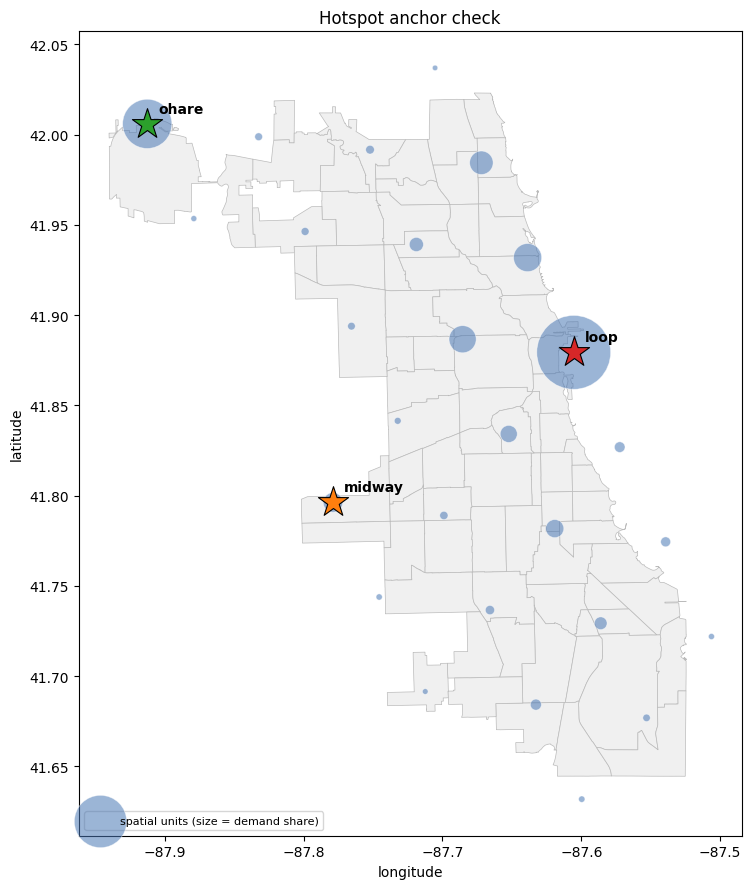

In [7]:
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPoly
from matplotlib.collections import PatchCollection

def plot_hotspot_check(panel, anchors, centroid_fn=_h3_centroids,
                       geojson_path="../data/chicago_community_areas.geojson"):
    """Sanity-check map: city boundaries + all spatial units sized by demand
    share, with the detected hotspot anchors starred. Works at any resolution
    as long as centroid_fn matches the panel's spatial id type."""
    tot = panel.groupby("location_id")["demand_count"].sum()
    lat, lon = centroid_fn(tot.index.to_series())
    share = tot.values / tot.values.sum() * 100

    fig, ax = plt.subplots(figsize=(8, 9))

    # boundaries for context
    gj = json.load(open(geojson_path))
    patches = []
    for f in gj["features"]:
        g = f["geometry"]
        polys = g["coordinates"] if g["type"] == "MultiPolygon" else [g["coordinates"]]
        for poly in polys:
            patches.append(MplPoly(np.array(poly[0]), closed=True))
    ax.add_collection(PatchCollection(patches, facecolor="#f0f0f0",
                      edgecolor="#bbbbbb", linewidths=0.5, zorder=0))

    ax.scatter(lon, lat, s=share * 60 + 15, c="#4a78b5", alpha=0.55,
               edgecolor="white", linewidth=0.5, zorder=2,
               label="spatial units (size = demand share)")

    colors = {"loop": "#d62728", "ohare": "#2ca02c", "midway": "#ff7f0e"}
    for name, loc in anchors.items():
        a_lat, a_lon = centroid_fn(pd.Series([loc]))
        ax.scatter(a_lon, a_lat, marker="*", s=520, c=colors.get(name, "#555"),
                   edgecolor="black", linewidth=0.8, zorder=4)
        ax.annotate(name, (a_lon.iloc[0], a_lat.iloc[0]), xytext=(8, 8),
                    textcoords="offset points", fontsize=10, fontweight="bold", zorder=5)

    ax.set(xlabel="longitude", ylabel="latitude", title="Hotspot anchor check")
    ax.set_aspect(1.3); ax.legend(loc="lower left", fontsize=8)
    plt.tight_layout(); plt.show()

plot_hotspot_check(df, anchors_preview)

#### Design decisions and justification

**Target.** The prediction target is `demand_count`, the number of trips originating in a spatial unit during a time bucket. The panel is zero-filled, so the absence of trips is represented as an observation of zero rather than a missing row, which is required for the model to learn low-demand conditions rather than only observed trips.

**Calendar encoding.** Hour-of-day, day-of-week, and month are periodic quantities, so each is encoded as a sine/cosine pair rather than a raw integer. This preserves continuity across the period boundary (23:00 is adjacent to 00:00, December to January), which an ordinal encoding would misrepresent as maximally distant. A binary weekend indicator is added because demand shifts between commuting and leisure regimes that are not fully captured by the day-of-week cycle alone.

**Spatial encoding.** Each spatial unit is represented by its centroid latitude and longitude rather than by a one-hot indicator per cell. Continuous coordinates encode relative position and distance, allowing the support vector machine and neural network to share information between neighbouring units and to generalise across space, which directly supports location-conditioned queries such as demand "around the outskirts". One-hot encoding would treat every unit as an unordered, independent category, add one column per cell, and prevent any spatial generalisation. This would scale poorly with the number of features and degrades further at finer resolution. The centroid is derived deterministically from the H3 cell identifier, so reframing the retained spatial label as coordinates introduces no information loss.

**Hotspot distances.** Section 2 identified three dominant demand centres, the downtown core, and O'Hare and Midway airports. The Euclidean distance from each unit to these three anchors is added as an explicit feature. These distances are deterministic transforms of the centroid coordinates and therefore add no new information in principle, but they supply a coordinate frame aligned with the observed demand structure, which finite-sample SVM and neural-network models exploit more readily than raw coordinates. Three additional columns is a negligible dimensional cost. The anchors are identified from training data only and are not hard-coded, so the procedure transfers to other spatial resolutions (see 3.7). Distances are expressed in miles for consistency with the trip-level distance fields.

**Weather data.** The weather features are carried over exactly as aggregated in Section 1 with any redundancy (precipitation overlapping rain and snow) and the encoding of the categorical weather code left to the model stage.

**Leakage control.** The per-bucket trip aggregates (`avg_trip_miles`, `avg_trip_seconds`, `avg_trip_total`, `n_unique_taxis`) are excluded from the feature matrix. They are computed from the same trips that define the target and are therefore unavailable at prediction time. Consistent with the task framing, no lagged or same-bucket demand of the target enters the features and prediction is conditioned only on calendar, weather, and spatial position. The constant metadata columns (`spatial_resolution`, `temporal_resolution`) are also dropped. 

**Output.** The result is a feature matrix `X`, target `y`, and a `feature_names` list reused unchanged by the validation harness (3.2) and both model families (3.3-3.6), ensuring that all reported metrics are comparable.

| Feature | Group | Type | Meaning |
|---|---|---|---|
| `demand_count` | target | int | trips originating in a cell × 4h bucket (prediction target) |
| `hour_sin` / `hour_cos` | calendar | float | time-of-day (4h buckets), cyclical encoding |
| `dow_sin` / `dow_cos` | calendar | float | day-of-week, cyclical encoding |
| `month_sin` / `month_cos` | calendar | float | month/season, cyclical encoding |
| `is_weekend` | calendar | int (0/1) | weekend flag |
| `cell_lat` | spatial | float | cell centroid latitude |
| `cell_lon` | spatial | float | cell centroid longitude |
| `dist_to_loop_mi` | spatial | float | miles to downtown core |
| `dist_to_ohare_mi` | spatial | float | miles to O'Hare |
| `dist_to_midway_mi` | spatial | float | miles to Midway |
| `temp_4h` | weather | float | avg temperature (°F) |
| `rain_4h` | weather | float | total rainfall accumulated |
| `snow_4h` | weather | float | total snowfall accumulated |
| `precip_4h` | weather | float | total precipitation accumulated |
| `wind_speed_4h` | weather | float | avg wind speed |
| `weather_code_4h` | weather | int (categorical) | max weather condition code |

### 3.2 Validation strategy

A single validation procedure is defined and reused across both model families, so all reported numbers stay comparable. Because the target is demand conditioned on calendar, weather, and location, not on past demand, this is a supervised regression problem rather than a forecasting one, and cross-validation is used for full seasonal coverage, with one adjustment for the non-independence of observations.

**Grouping by day.** The 4-hour buckets of a given day and cell share weather, calendar values, and unobserved local shocks. A purely random split could place some of a day's buckets in training and the rest in test, letting the model exploit day-specific signal absent from the features and inflating the score. All splits are therefore **grouped by calendar day**, so a day appears entirely in one partition or the other, never both.

**Final holdout.** A grouped random sample of whole calendar days (15%) is set aside as an untouched test set, used only for the SVM-vs-NN comparison in 3.8. The sample is drawn from across the entire date range rather than one trailing block, which keeps every season represented, not just a single recent stretch. All 27 spatial cells appear in both partitions, since prediction is for known cells under unseen conditions, not unseen cells.

**Cross-validation.** Model selection uses `GroupKFold` (5 folds, group = day) over the development set. Hyperparameter search (3.4) and network tuning (3.6) operate only within these folds. The holdout is never touched during tuning.

**Fit-on-train-only.** The two data-derived steps from 3.1, the hotspot anchors and feature standardisation, are fitted on training data only. Standardisation and the target transform are wrapped in a pipeline so they are refit inside each CV fold automatically.

**Target transform.** Demand is heavily right-skewed with 12.6% zeros, so it is modelled on a `log1p` scale and predictions are inverted (`expm1`) before scoring.

**Metrics.** A shared `evaluate()` reports MAE, RMSE, and R2 on the original demand scale (trips per cell per 4-hour bucket), with negative predictions clipped to zero. All downstream subsections reuse this single function, so results stay comparable.

In [8]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE  = 42
TEST_FRACTION = 0.15      # share of DAYS held out for the final comparison
N_CV_SPLITS   = 5

# group key: one group per calendar day (keeps a day's buckets together)
df = df.copy()
df["day"] = df["timestamp"].dt.floor("D")

# final holdout: whole days, drawn across the full sample (all seasons)
gss = GroupShuffleSplit(n_splits=1, test_size=TEST_FRACTION, random_state=RANDOM_STATE)
dev_idx, test_idx = next(gss.split(df, groups=df["day"]))
dev_panel  = df.iloc[dev_idx].copy()      # training + cross-validation (model selection)
test_panel = df.iloc[test_idx].copy()     # untouched until 3.8
assert set(dev_panel["day"]).isdisjoint(set(test_panel["day"]))   # no day shared

# hotspot anchors: fit on DEV (train) only, never on the holdout
anchors = detect_hotspot_anchors(dev_panel)
print("anchors (fit on dev/train):", anchors)

# build features for each partition with the SAME anchors
X_dev,  y_dev,  feature_names = build_features(dev_panel,  anchors)
X_test, y_test, _             = build_features(test_panel, anchors)

# group vector + splitter for cross-validation over the dev set
groups_dev = dev_panel["day"].values
cv = GroupKFold(n_splits=N_CV_SPLITS)     # use as: cv.split(X_dev, y_dev, groups_dev)

# shared estimator wrapper: standardise features + log1p target,
# both refit inside each CV fold, predictions returned on demand scale
def make_estimator(model):
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    return TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

# shared metric set (original demand scale) 
def evaluate(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)     # demand cannot be negative
    return {"MAE":  mean_absolute_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "R2":   r2_score(y_true, y_pred)}

print(f"dev:  {len(X_dev):>7d} rows | {dev_panel['day'].nunique()} days")
print(f"test: {len(X_test):>7d} rows | {test_panel['day'].nunique()} days "
      f"| months covered: {sorted(test_panel['timestamp'].dt.month.unique())}")
print("CV: GroupKFold, 5 folds, group = calendar day")

anchors (fit on dev/train): {'loop': '862664c1fffffff', 'ohare': '862759347ffffff', 'midway': '862664527ffffff'}
dev:   112941 rows | 698 days
test:   20088 rows | 124 days | months covered: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
CV: GroupKFold, 5 folds, group = calendar day


### 3.3 SVM - linear baseline (no kernel)

Following the assignment, the SVM is first specified without a kernel. Required outputs:

- Feature standardisation (SVMs are scale-sensitive), with the scaler fitted on the training partition only.
- A linear SVM regressor trained on the training split defined in 3.2.
- MAE, RMSE, and R2 on the holdout using the common metric set.
- A brief interpretation of which features carry weight and of the practical meaning of the error (e.g. average deviation in trips per cell per 4h bucket).

In [6]:
# Grid search over C and epsilon. Can take a while, the fitted result is saved to /models below.
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVR

svm_linear_base = make_estimator(
    LinearSVR(
        max_iter=20_000,
        random_state=RANDOM_STATE
    )
)

param_grid = {
    "regressor__model__C": [0.1, 1.0, 10.0],
    "regressor__model__epsilon": [0.0, 0.05, 0.1, 0.2]
}

svm_linear_search = GridSearchCV(
    estimator=svm_linear_base,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=GroupKFold(n_splits=3),
    n_jobs=-1
)

svm_linear_search.fit(X_dev, y_dev, groups=groups_dev)

svm_linear_search.best_params_, -svm_linear_search.best_score_

({'regressor__model__C': 10.0, 'regressor__model__epsilon': 0.0},
 np.float64(66.92883650409134))

In [7]:
# new
svm_linear = svm_linear_search.best_estimator_

y_pred_svm_linear = svm_linear.predict(X_test)
y_pred_svm_linear = np.clip(y_pred_svm_linear, 0, None)

svm_linear_metrics = evaluate(y_test, y_pred_svm_linear)
svm_linear_metrics

{'MAE': 64.10012432467434,
 'RMSE': np.float64(196.92452644294656),
 'R2': 0.6562638031437289}

The linear SVM baseline achieves an MAE of 64.10 and an R² of 0.656 on the holdout set. This indicates that the model captures relevant spatial, temporal and weather-related demand patterns, but the high RMSE of 196.92 shows that large demand peaks are still difficult to predict. This is expected because the current model is purely linear and cannot capture stronger non-linear interactions between location, time and weather. Therefore, kernel-based SVMs are considered next.

In [8]:
coef = pd.Series(svm_linear.regressor_.named_steps["model"].coef_, index=feature_names)
coef.sort_values(key=abs, ascending=False)

dist_to_loop_mi     -2.685483
precip_4h            2.658153
rain_4h             -2.589360
cell_lat            -2.581824
dist_to_midway_mi    1.789556
cell_lon            -1.310682
dist_to_ohare_mi    -1.268505
hour_cos            -0.633374
snow_4h             -0.582142
is_weekend          -0.089089
month_cos           -0.071396
hour_sin             0.066741
dow_cos             -0.024313
month_sin            0.023291
temp_4h              0.016513
wind_speed_4h       -0.008108
dow_sin             -0.005381
weather_code_4h      0.002882
dtype: float64

The five largest-magnitude coefficients are all spatial (dist_to_loop_mi, cell_lat, dist_to_midway_mi, dist_to_ohare_mi, cell_lon), each an order of magnitude larger than every calendar or weather feature. hour_cos is a distant second tier, and weather features (rain_4h, precip_4h, etc.) contribute comparatively little. This is consistent with demand being driven primarily by location, with time-of-day and weather acting as secondary modulators. Because cell_lat, cell_lon, and the three anchor distances are deterministic transforms of the same coordinates (3.1), they are mutually correlated, so individual signs and magnitudes should be read as "location matters a lot" rather than as clean, independent marginal effects.

In [9]:
svm_linear_results = pd.DataFrame({
    "actual": y_test,
    "predicted": np.clip(y_pred_svm_linear, 0, None)
})

svm_linear_results.head()

,actual,predicted
30,0.0,0.637207
31,4.0,1.849066
32,2.0,5.334846
33,8.0,8.134505
34,4.0,4.315524


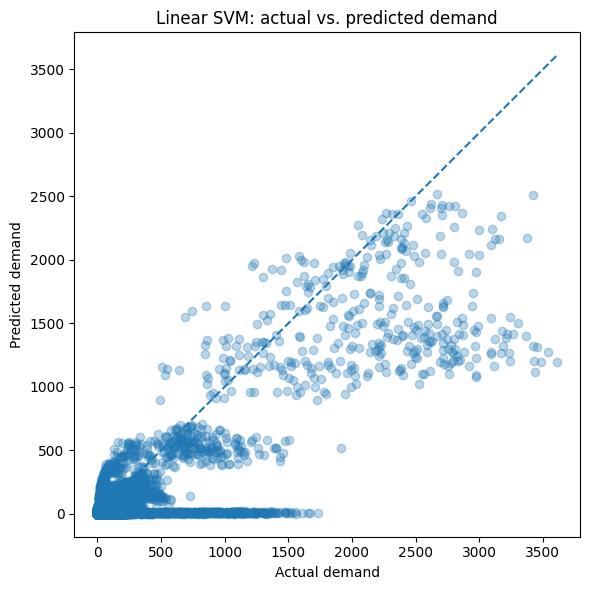

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(
    svm_linear_results["actual"],
    svm_linear_results["predicted"],
    alpha=0.3
)
plt.plot(
    [svm_linear_results["actual"].min(), svm_linear_results["actual"].max()],
    [svm_linear_results["actual"].min(), svm_linear_results["actual"].max()],
    linestyle="--"
)
plt.xlabel("Actual demand")
plt.ylabel("Predicted demand")
plt.title("Linear SVM: actual vs. predicted demand")
plt.tight_layout()
plt.show()

In [11]:
# save the model to not run the gridsearch again
import joblib

joblib.dump(svm_linear_search.best_estimator_, "../models/svm_linear_best.pkl")

# load the model (if you need to)
#svm_linear = joblib.load("../models/svm_linear_best.pkl")

['../models/svm_linear_best.pkl']

### 3.4 SVM - kernels and grid search

Model complexity is increased through non-linear kernels with tuned hyperparameters. Required outputs:

- RBF and, optionally, polynomial kernels.
- A grid search over the relevant hyperparameters (`C`, `gamma`, `epsilon`) on the training and validation folds only. As SVR scales poorly with sample size, a justified subsample or representative training slice may be used.
- Best hyperparameters and holdout performance reported against the linear baseline.
- An evaluation of model quality and a discussion of its shortfalls.

In [12]:
rng = np.random.default_rng(RANDOM_STATE)

unique_days = np.unique(groups_dev)
tune_days = rng.choice(unique_days, size=min(120, len(unique_days)), replace=False)

tune_mask = np.isin(groups_dev, tune_days)

X_tune = X_dev[tune_mask]
y_tune = y_dev[tune_mask]
groups_tune = groups_dev[tune_mask]

print(f"tuning sample: {len(X_tune)} rows | {len(tune_days)} days")
print(f"final fit: {len(X_dev)} rows | {len(unique_days)} days")

tuning sample: 19440 rows | 120 days
final fit: 112941 rows | 698 days


In [13]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, GroupKFold

svm_rbf_base = make_estimator(
    SVR(
        kernel="rbf",
        cache_size=1000
    )
)

rbf_param_grid = {
    "regressor__model__C": [1.0, 10.0, 100.0],
    "regressor__model__gamma": ["scale", 0.01, 0.1],
    "regressor__model__epsilon": [0.1, 0.2]
}

svm_rbf_search = GridSearchCV(
    estimator=svm_rbf_base,
    param_grid=rbf_param_grid,
    scoring="neg_mean_absolute_error",
    cv=GroupKFold(n_splits=3),
    n_jobs=-1,
    verbose=1
)

svm_rbf_search.fit(X_tune, y_tune, groups=groups_tune)

svm_rbf_search.best_params_, -svm_rbf_search.best_score_

Fitting 3 folds for each of 18 candidates, totalling 54 fits


({'regressor__model__C': 10.0,
  'regressor__model__epsilon': 0.1,
  'regressor__model__gamma': 0.1},
 np.float64(34.02259864789156))

In [14]:
# best_estimator_ is already refit on X_tune by GridSearchCV(refit=True), a full X_dev refit was tried but too slow
svm_rbf = svm_rbf_search.best_estimator_

In [15]:
y_pred_svm_rbf = svm_rbf.predict(X_test)
y_pred_svm_rbf = np.clip(y_pred_svm_rbf, 0, None)

svm_rbf_metrics = evaluate(y_test, y_pred_svm_rbf)
svm_rbf_metrics

{'MAE': 30.83820073603816,
 'RMSE': np.float64(118.91037260452616),
 'R2': 0.8746670886524418}

In [16]:
svm_comparison = pd.DataFrame([
    {"model": "Linear SVM", **svm_linear_metrics},
    {"model": "RBF SVM", **svm_rbf_metrics}
])

svm_comparison

,model,MAE,RMSE,R2
0,Linear SVM,64.100124,196.924526,0.656264
1,RBF SVM,30.838201,118.910373,0.874667


The RBF SVM clearly outperforms the linear SVM on the holdout set. MAE decreases from 64.10 to 30.84 trips per spatial-time bucket, which means the average absolute prediction error is reduced by more than half. RMSE also drops substantially from 196.92 to 118.91, showing that the RBF model handles larger demand errors and peak-demand situations better than the linear baseline.

The R² increases from 0.656 to 0.875, meaning that the RBF SVM explains a much larger share of the variation in taxi demand. This confirms that demand is not purely linear in the available features. Non-linear interactions between location, time of day, weekday patterns and weather appear to be important for predicting taxi demand.

However, the better predictive performance comes at a computational cost. The RBF SVM was much slower to train than the linear SVM and could not be efficiently refitted on the full development set. Therefore, the RBF model is a stronger non-linear benchmark, but its scalability is more limited than the linear model.

In [17]:
joblib.dump(svm_rbf, "../models/svm_rbf_best.pkl")

# load the model (if you need to)
#svm_rbf = joblib.load("../models/svm_rbf_best.pkl")

['../models/svm_rbf_best.pkl']

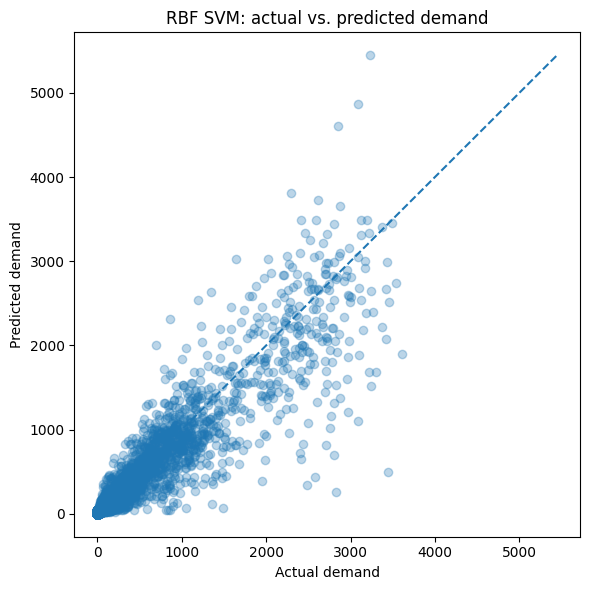

In [18]:
svm_rbf_results = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred_svm_rbf
})

plt.figure(figsize=(6, 6))
plt.scatter(
    svm_rbf_results["actual"],
    svm_rbf_results["predicted"],
    alpha=0.3
)

max_val = max(
    svm_rbf_results["actual"].max(),
    svm_rbf_results["predicted"].max()
)

plt.plot([0, max_val], [0, max_val], linestyle="--")
plt.xlabel("Actual demand")
plt.ylabel("Predicted demand")
plt.title("RBF SVM: actual vs. predicted demand")
plt.tight_layout()
plt.show()

### 3.5 Neural network - feedforward baseline

The procedure of the SVM subsections is repeated with a feedforward neural network.

- Reuse of the same feature matrix, splits, scaling, and metrics from 3.1-3.2 so that the later comparison is fair.
- A feedforward multilayer perceptron: an input layer sized to the feature count, several hidden layers with non-linear activations, and a single linear output for the demand regression.
- Training with early stopping on the validation fold, and MAE, RMSE, and R2 on the holdout.
- A statement of the loss, optimiser, and stopping criterion and the reasons for their selection.

In [1]:
import pathlib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import cross_validate, ParameterGrid
from sklearn.utils.validation import check_is_fitted
import shap
import matplotlib.gridspec as gridspec

In [12]:
# Pytorch architecture: simple feedforward net with a configurable number of hidden layers (widths set by hidden_sizes), ReLU activations, and dropout.
class _PytorchModel(nn.Module):
    def __init__(self, n_features: int, hidden_sizes: tuple, dropout: float, activation=nn.ReLU):
        super().__init__()
        layers = []
        in_dim = n_features
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(activation())
            layers.append(nn.Dropout(dropout))
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(-1)

In [13]:
# Sklearn-compatible wrapper around the Pytorch model
class PytorchRegressor(BaseEstimator, RegressorMixin):
    """
    Inherits BaseEstimator  -> get_params/set_params -> GridSearchCV / ParameterGrid work.
    Inherits RegressorMixin -> score() and regressor tagging for Pipeline / cross_validate.
        Parameters
    ----------
    hidden_sizes  : tuple of ints   widths of hidden layers
    dropout       : float           dropout probability (0 = disabled)
    lr            : float           Adam learning rate
    batch_size    : int
    max_epochs    : int             upper bound; early stopping may halt sooner
    patience      : int             early-stopping patience (epochs without val improvement)
    val_fraction  : float           share of the data passed to fit() held out for early stopping. For example, 0.15 means 85% is used for training and 15% for monitoring when to stop.
    """
    
    def __init__(
            self,
            hidden_sizes = (64,),
            dropout      = 0.2,
            lr           = 1e-3,
            batch_size   = 512,
            max_epochs   = 150,
            patience     = 15,
            val_fraction = 0.1,
            random_state=42):
        self.hidden_sizes = hidden_sizes
        self.dropout = dropout
        self.lr = lr
        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.patience = patience
        self.val_fraction = val_fraction
        self.random_state = random_state

    def fit(self, X, y):
        torch.manual_seed(self.random_state)
        np.random.seed(self.random_state)

        X_arr = np.asarray(X, dtype=np.float32)
        y_arr = np.asarray(y, dtype=np.float32) 

        # Internal val split for early stopping
        n_val = max(1, int(len(X_arr) * self.val_fraction))
        idx   = np.random.permutation(len(X_arr))
        X_tr, y_tr = X_arr[idx[n_val:]], y_arr[idx[n_val:]]
        X_vl, y_vl = X_arr[idx[:n_val]], y_arr[idx[:n_val]]

        train_loader = DataLoader(
            TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
            batch_size=self.batch_size, shuffle=True,
        )


        self.model_ = _PytorchModel(n_features=X.shape[1], hidden_sizes=self.hidden_sizes,
                                   dropout=self.dropout).to("cpu")
        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
        criterion     = nn.MSELoss()
        X_vl_t        = torch.from_numpy(X_vl)
        y_vl_t        = torch.from_numpy(y_vl)

        best_val      = float("inf")
        no_improve    = 0
        self.train_losses_ = []
        self.val_losses_   = []
        self.best_epoch_   = 0

        for epoch in range(self.max_epochs):
            # training step
            self.model_.train()
            epoch_loss = 0
            for X_batch, y_batch in train_loader:
                optimizer.zero_grad()
                preds = self.model_(X_batch)
                loss = criterion(preds, y_batch)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()*len(X_batch)
            self.train_losses_.append(epoch_loss / len(X_tr))

            # validation step
            self.model_.eval()
            with torch.no_grad():
                val_loss = criterion(self.model_(X_vl_t), y_vl_t).item()
            self.val_losses_.append(val_loss)

            # early stopping: save best weights
            if val_loss < best_val - 1e-6:
                best_val           = val_loss
                no_improve         = 0
                self.best_epoch_   = epoch
                self._best_state   = {k: v.clone() for k, v in self.model_.state_dict().items()}
            else:
                no_improve += 1
                if no_improve >= self.patience:
                    break

        self.model_.load_state_dict(self._best_state)   # restore best weights
        self.n_features_in_ = X_arr.shape[1]
        return self

    def predict(self, X):
        self.model_.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(np.asarray(X, dtype=np.float32))
            preds = self.model_(X_tensor).cpu().numpy()
        return preds
    
    def get_loss_history(self):
        """Return (train_losses, val_losses, best_epoch) for plotting."""
        check_is_fitted(self, "train_losses_")
        return self.train_losses_, self.val_losses_, self.best_epoch_

In [ ]:
# Baseline architecture:
# default parameters defined in the cell above
# Input -> ReLU(64) + Dropout -> Linear(1)
nn_baseline_est = make_estimator(PytorchRegressor(
    random_state=RANDOM_STATE))

cv_res_base = cross_validate(
    nn_baseline_est, X_dev, y_dev,
    groups             = groups_dev,
    cv                 = cv,
    scoring            = {
        "MAE":  "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error",
        "R2":   "r2",
    },
    return_train_score = True,
    n_jobs             = 1,      # PyTorch + forked workers can deadlock, so keep sequential
)

print(f"Baseline CV  (GroupKFold 5-fold):")
print(f"  MAE  : {-cv_res_base['test_MAE'].mean():.4f}  ±  {cv_res_base['test_MAE'].std():.4f}")
print(f"  RMSE : {-cv_res_base['test_RMSE'].mean():.4f}  ±  {cv_res_base['test_RMSE'].std():.4f}")
print(f"  R²   : { cv_res_base['test_R2'].mean():.4f}  ±  {cv_res_base['test_R2'].std():.4f}")

Baseline CV  (GroupKFold 5-fold):
  MAE  : 29.4088  ±  0.8697
  RMSE : 103.7475  ±  5.1104
  R²   : 0.9111  ±  0.0094


In [ ]:
# Fit on full dev set and evaluate on test set
nn_baseline_est.fit(X_dev, y_dev)
y_pred_nn_baseline = nn_baseline_est.predict(X_test)
metrics_nn_baseline = evaluate(y_test, y_pred_nn_baseline)

print("Baseline test set performance:")
for metric, value in metrics_nn_baseline.items():
    print(f"  {metric}: {value:.4f}")   

Baseline test set performance:
  MAE: 26.7536
  RMSE: 91.3579
  R2: 0.9260


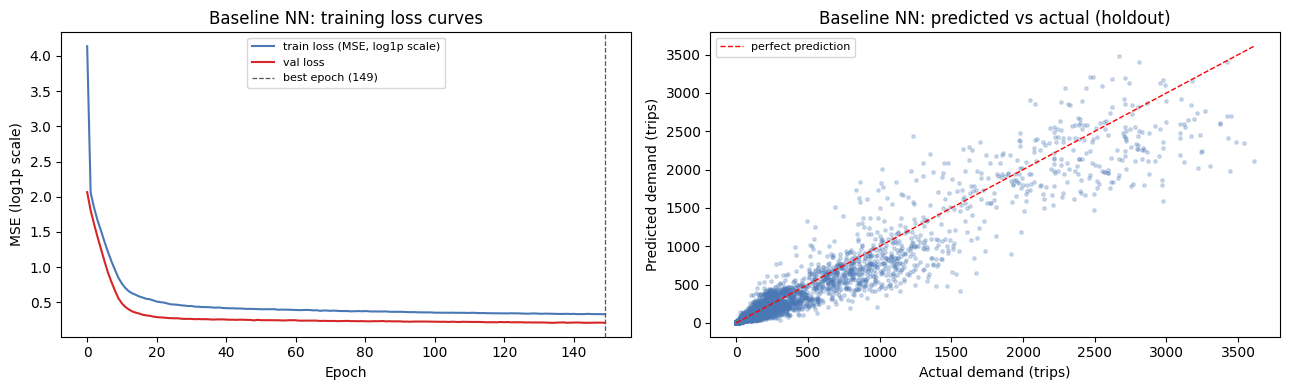

In [ ]:
# Loss curves + predicted vs actual
inner_model = nn_baseline_est.regressor_.named_steps["model"]
tr_loss, vl_loss, best_ep = inner_model.get_loss_history()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# loss curves
ax = axes[0]
ax.plot(tr_loss, label="train loss (MSE, log1p scale)", color="#4a78b5")
ax.plot(vl_loss, label="val loss",                      color="#d62728")
ax.axvline(best_ep, color="#555", linestyle="--", linewidth=0.9,
           label=f"best epoch ({best_ep})")
ax.set(xlabel="Epoch", ylabel="MSE (log1p scale)",
       title="Baseline NN: training loss curves")
ax.legend(fontsize=8)

# predicted vs actual
ax = axes[1]
y_pred_clipped = np.clip(y_pred_nn_baseline, 0, None)
ax.scatter(y_test, y_pred_clipped, alpha=0.25, s=6, color="#4a78b5")
lim = max(y_test.max(), y_pred_clipped.max())
ax.plot([0, lim], [0, lim], "r--", linewidth=1, label="perfect prediction")
ax.set(xlabel="Actual demand (trips)", ylabel="Predicted demand (trips)",
       title="Baseline NN: predicted vs actual (holdout)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Takeaway from 3.5

**Baseline architecture**: One hidden layer with 64 nodes and ReLU activation. Dropout is set to 0.2, meaning 20% of the nodes are randomly disabled on each training pass. This reduces co-dependence between neurons and keeps the model from relying too heavily on any single one.

**Loss function.** MSE on the log1p-scaled target. Because `make_estimator` wraps the  
network inside `TransformedTargetRegressor`, the PyTorch model always trains on  
log1p(demand) and predictions are automatically inverted via expm1 before `evaluate()`.

**Optimiser.** Adam with lr=1e-3.

**Early stopping.** Patience=15 epochs on an internal 10 % validation split drawn from the training fold. This prevents overfitting without requiring a fixed epoch budget, and the best weights are restored before the model is returned. This internal split does not overlap with the outer CV folds or the final holdout.

| Variable | Content |
|---|---|
| `nn_baseline_est` | Fitted estimator (scaler + base PyTorch model + log1p wrapper) of baseline Neural Network model|
| `metrics_nn_baseline` | `{"MAE": 26.7536, "RMSE": 91.3579, "R2": 0.9260}` on holdout |
| `y_pred_nn_baseline` | Predicted demand in test dataset |

### 3.6 Neural network - tuning

Required outputs:

- Exploration of architecture and regularisation: number and width of layers, dropout, learning rate, batch size, and epochs.
- All tuning confined to the training and validation folds, with a single final holdout evaluation.
- The resulting holdout metrics recorded for the comparison in 3.8, alongside a note on whether performance differs materially from the SVM.

In [ ]:
# Tuning the baseline architecture with manual grid search
# Parameters to tune:
# - hidden_sizes: architecture depth and width
# - dropout: regularisation strength
# - lr: learning rate
# - batch_size: training batch size
PARAM_GRID = list(ParameterGrid({
    "hidden_sizes" : [(64,), (64, 32), (128, 64, 32)],
    "dropout"      : [0.1, 0.2],
    "lr"           : [3e-3, 1e-3, 3e-4],
    "batch_size"   : [256, 512], 
})) 

cv_search = GroupKFold(n_splits=3)             # cheaper than the final 5-fold cv, screening only

result = []
for i, params in enumerate(PARAM_GRID):
    print(f"Running config {i+1}/{len(PARAM_GRID)}: {params}")
    est = make_estimator(PytorchRegressor(**params))
    cv_res = cross_validate(
        est, X_dev, y_dev,
        groups             = groups_dev,
        cv                 = cv_search,
        scoring            = "neg_mean_absolute_error",
        return_train_score = False,
        return_estimator   = True,   # keep fitted folds to read training diagnostics
        n_jobs             = 1,
    )
    mean_mae = -cv_res["test_score"].mean()
    std_mae  = cv_res["test_score"].std()
    best_epochs = [e.regressor_.named_steps["model"].best_epoch_ for e in cv_res["estimator"]]
    print(f"  MAE: {mean_mae:.4f} ± {std_mae:.4f} | best epoch per fold: {best_epochs}")
    result.append({"params": params, "MAE_mean": mean_mae, "MAE_std": std_mae})

Running config 1/36: {'batch_size': 256, 'dropout': 0.1, 'hidden_sizes': (64,), 'lr': 0.003}
  MAE: 27.1391 ± 0.7700 | best epoch per fold: [103, 120, 86]
Running config 2/36: {'batch_size': 256, 'dropout': 0.1, 'hidden_sizes': (64,), 'lr': 0.001}
  MAE: 28.8819 ± 0.9982 | best epoch per fold: [63, 148, 146]
Running config 3/36: {'batch_size': 256, 'dropout': 0.1, 'hidden_sizes': (64,), 'lr': 0.0003}
  MAE: 30.2858 ± 0.2141 | best epoch per fold: [149, 148, 147]
Running config 4/36: {'batch_size': 256, 'dropout': 0.1, 'hidden_sizes': (64, 32), 'lr': 0.003}
  MAE: 26.3699 ± 1.1199 | best epoch per fold: [30, 20, 45]
Running config 5/36: {'batch_size': 256, 'dropout': 0.1, 'hidden_sizes': (64, 32), 'lr': 0.001}
  MAE: 25.6920 ± 1.0093 | best epoch per fold: [59, 49, 57]
Running config 6/36: {'batch_size': 256, 'dropout': 0.1, 'hidden_sizes': (64, 32), 'lr': 0.0003}
  MAE: 25.5659 ± 0.7184 | best epoch per fold: [127, 92, 119]
Running config 7/36: {'batch_size': 256, 'dropout': 0.1, 'hidd

In [ ]:
# Refit the best model on the full dev set and evaluate on the test set
best_params = min(result, key=lambda x: x["MAE_mean"])["params"]

print("Best hyperparameters:", best_params)
best_est = make_estimator(PytorchRegressor(**best_params))
best_est.fit(X_dev, y_dev)
y_pred_best = best_est.predict(X_test)
metrics_best = evaluate(y_test, y_pred_best)
print("Best model test set performance:")
for metric, value in metrics_best.items():
    print(f"  {metric}: {value:.4f}")   

Best hyperparameters: {'batch_size': 256, 'dropout': 0.1, 'hidden_sizes': (128, 64, 32), 'lr': 0.0003}
Best model test set performance:
  MAE: 19.3523
  RMSE: 69.9275
  R2: 0.9567


In [ ]:
print(df["demand_count"].describe())
print(f"% zeros: {(df['demand_count']==0).mean()*100:.1f}%")

count    133029.000000
mean        108.118245
std         346.661425
min           0.000000
25%           3.000000
50%          11.000000
75%          52.000000
max        4098.000000
Name: demand_count, dtype: float64
% zeros: 12.6%


**The best model.**
- The average `demand_count` in the dataset is 108, but the distribution is heavily right-skewed (median 11, 75th percentile 52). The tuned model's MAE is 19.35, about 18% of that average, which looks favourable partly because the average itself is pulled up by a few high-demand hotspots rather than reflecting a typical cell.
- RMSE (69.93) is much larger than MAE, consistent with the model making large absolute errors on the few spatial units with very high demand, since a metric that squares errors before averaging is dominated by the largest misses. This reflects the scale of the target rather than a training shortfall, and it describes absolute error only, not relative accuracy per cell.
- R2 = 0.957, meaning the model explains about 96% of the variance in demand, compared with a naive model that always predicts the average.

C:\Users\katig\AppData\Local\Temp\ipykernel_21848\3509792881.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


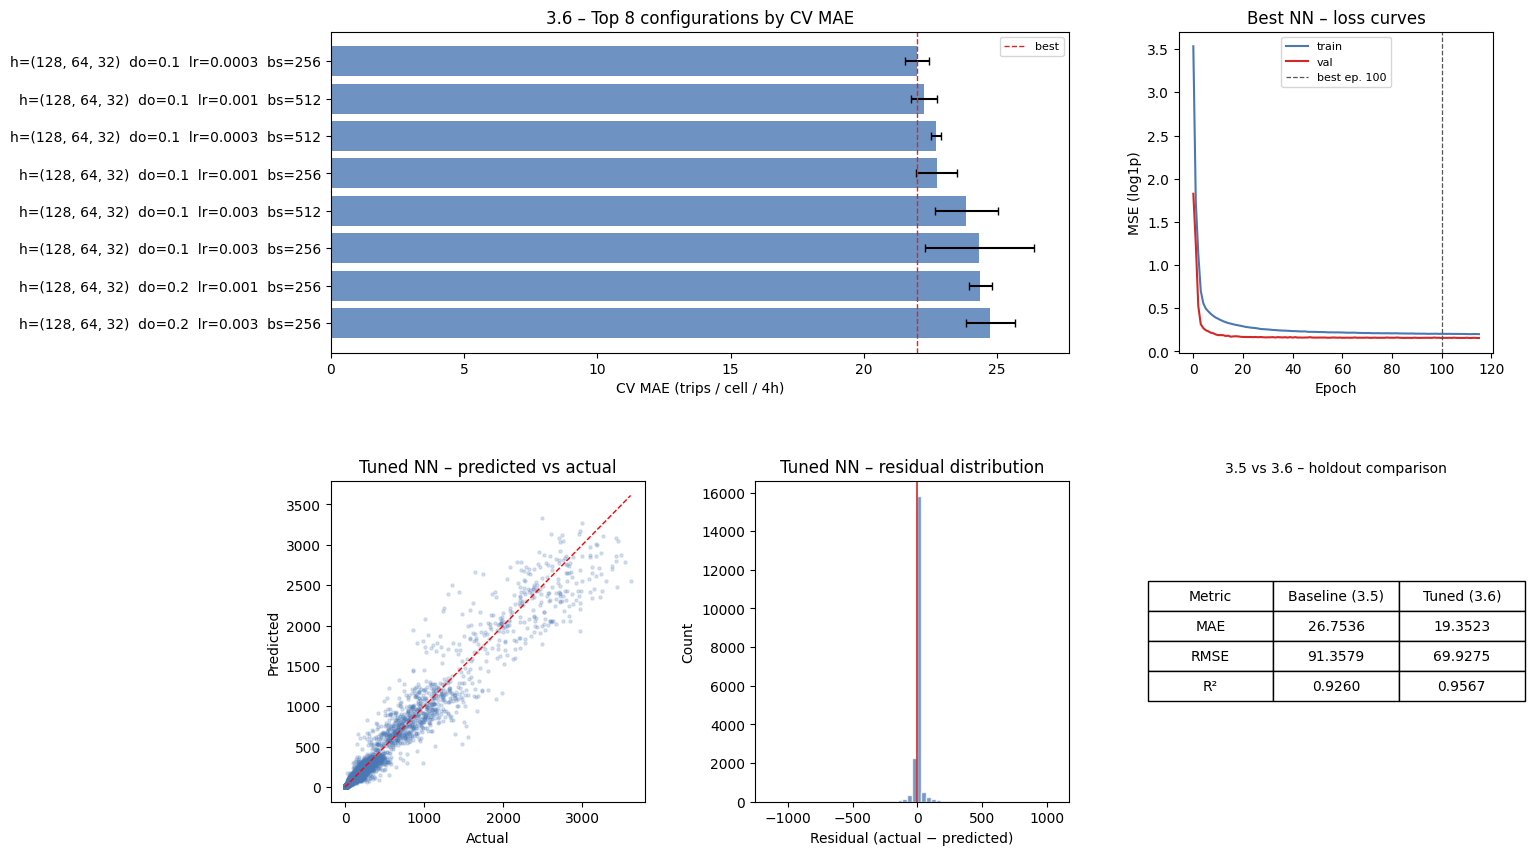

In [ ]:
# Visualise the best model's predictions vs actuals
result_df = pd.DataFrame(result).sort_values('MAE_mean').reset_index(drop=True)
fig = plt.figure(figsize=(15, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

# CV MAE bar chart: top 8 configurations
ax0 = fig.add_subplot(gs[0, :2])
top8 = result_df.head(8).copy()
top8["label"] = [
    f"h={r.get('hidden_sizes')}  do={r.get('dropout')}  lr={r.get('lr')}  bs={int(r.get('batch_size'))}"
    for r in top8.params
]
ax0.barh(top8["label"][::-1], top8["MAE_mean"][::-1],
         xerr=top8["MAE_std"][::-1],
         color="#4a78b5", alpha=0.8, capsize=3)
ax0.axvline(result_df.iloc[0]["MAE_mean"], color="#d62728",
            linestyle="--", linewidth=1, label="best")
ax0.set(xlabel="CV MAE (trips / cell / 4h)",
        title="3.6 – Top 8 configurations by CV MAE")
ax0.legend(fontsize=8)

# Loss curves of the best model
ax1 = fig.add_subplot(gs[0, 2])
inner_best = best_est.regressor_.named_steps["model"]
tr_b, vl_b, ep_b = inner_best.get_loss_history()
ax1.plot(tr_b, label="train", color="#4a78b5")
ax1.plot(vl_b, label="val",   color="#d62728")
ax1.axvline(ep_b, color="#555", linestyle="--", linewidth=0.9,
            label=f"best ep. {ep_b}")
ax1.set(xlabel="Epoch", ylabel="MSE (log1p)",
        title="Best NN – loss curves")
ax1.legend(fontsize=8)

# Predicted vs actual (holdout)
ax2 = fig.add_subplot(gs[1, 0])
ypc = np.clip(y_pred_best, 0, None)
ax2.scatter(y_test, ypc, alpha=0.2, s=5, color="#4a78b5")
lim = max(y_test.max(), ypc.max())
ax2.plot([0, lim], [0, lim], "r--", linewidth=1)
ax2.set(xlabel="Actual", ylabel="Predicted",
        title="Tuned NN – predicted vs actual")

# Residual distribution
ax3 = fig.add_subplot(gs[1, 1])
residuals = y_test.values - ypc
ax3.hist(residuals, bins=60, color="#4a78b5", alpha=0.75, edgecolor="white")
ax3.axvline(0, color="#d62728", linewidth=1.2)
ax3.set(xlabel="Residual (actual − predicted)", ylabel="Count",
        title="Tuned NN – residual distribution")

# Baseline vs tuned comparison table
ax4 = fig.add_subplot(gs[1, 2])
ax4.axis("off")
table_data = [
    ["Metric", "Baseline (3.5)", "Tuned (3.6)"],
    ["MAE",    f"{metrics_nn_baseline['MAE']:.4f}",  f"{metrics_best['MAE']:.4f}"],
    ["RMSE",   f"{metrics_nn_baseline['RMSE']:.4f}", f"{metrics_best['RMSE']:.4f}"],
    ["R²",     f"{metrics_nn_baseline['R2']:.4f}",   f"{metrics_best['R2']:.4f}"],
]
tbl = ax4.table(cellText=table_data[1:], colLabels=table_data[0],
                loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)
ax4.set_title("3.5 vs 3.6 – holdout comparison", fontsize=10)

plt.tight_layout()
plt.show()

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
C:\Users\katig\AppData\Local\Temp\ipykernel_21848\1958735235.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain, feature_names=feature_names)


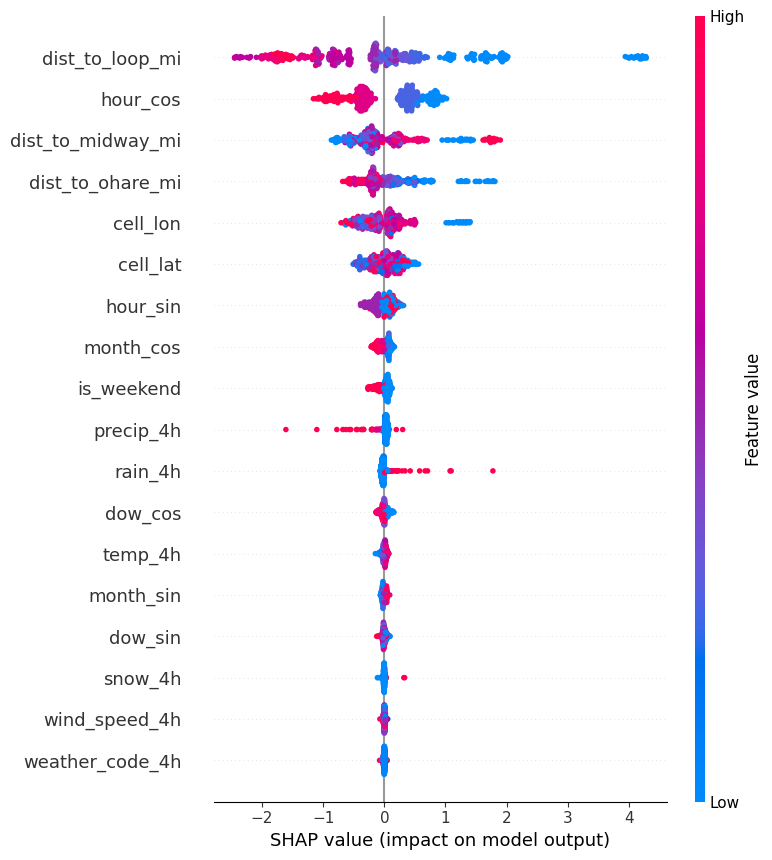

In [ ]:
# Feature importance by SHAP values
# SHAP values show how much each feature pushes an individual prediction up or down.

# Get the scaler and model from the best estimator's pipeline
scaler = best_est.regressor_.named_steps["scaler"]
model  = best_est.regressor_.named_steps["model"]

# Scale the data
X_dev_scaled = scaler.transform(X_dev)

# Use KernelExplainer with a small background sample
background   = shap.sample(X_dev_scaled, 200, random_state=RANDOM_STATE)
explainer    = shap.KernelExplainer(model.predict, background)


# Explain a sample (full X_dev is too slow)
X_explain    = shap.sample(X_dev_scaled, 500, random_state=RANDOM_STATE)
shap_values  = explainer.shap_values(X_explain, silent=True, l1_reg=0)
 
shap.summary_plot(shap_values, X_explain, feature_names=feature_names)

**SHAP summary plot**
- Y-axis: features ranked by importance (most important at top)
- X-axis: SHAP value, which indicates how much this feature pushed the prediction up (+) or down (-), on the model's log1p(demand) scale
- Each dot: one prediction from the sample

The graph shows that:
- The most important features are related to spatial unit, especially the **distance** from the hexagon to the busy areas. Low distance to Loop (blue dot) makes the demand increase, which means hexagons near the busy zones have high demand. This matches the linear SVM's coefficients in 3.3, where the same distance and location features were also the largest by magnitude.
- The **time features** (`hour_cos`, `hour_sin`) also rank highly, which means time of day matters a lot. For `is_weekend` the red dots (weekend = 1) sit slightly negative. It means that weekdays have slightly higher taxi demand overall.
- The **weather features** contribute little to demand, with SHAP values near 0.

In [ ]:
df_include_ypredict = pd.concat([
        test_panel['location_id'].reset_index(drop=True),
        X_test.reset_index(drop=True),
    pd.Series(y_test.values,    name="y_test"),
    pd.Series(y_pred_best,      name="y_pred_best"),
], axis=1)

df_include_ypredict["abs_error"] = (
    df_include_ypredict["y_test"] - df_include_ypredict["y_pred_best"]
).abs()

df_agg = (
    df_include_ypredict
    .groupby("location_id")
    .agg(MAE=("abs_error", "mean"), avg_demand=("y_test", "mean"))
    .reset_index()
)

In [ ]:
import h3
from shapely.geometry import Polygon

def h3_to_polygon(cell_id):
    """Return a Shapely Polygon for one H3 cell."""
    # h3.cell_to_boundary returns (lat, lon) pairs, swap to (lon, lat) for shapely
    boundary = h3.cell_to_boundary(cell_id)   # h3 v4
    # if h3 v3: h3.h3_to_geo_boundary(cell_id)
    return Polygon([(lon, lat) for lat, lon in boundary])

df_agg["geometry"] = df_agg["location_id"].apply(h3_to_polygon)

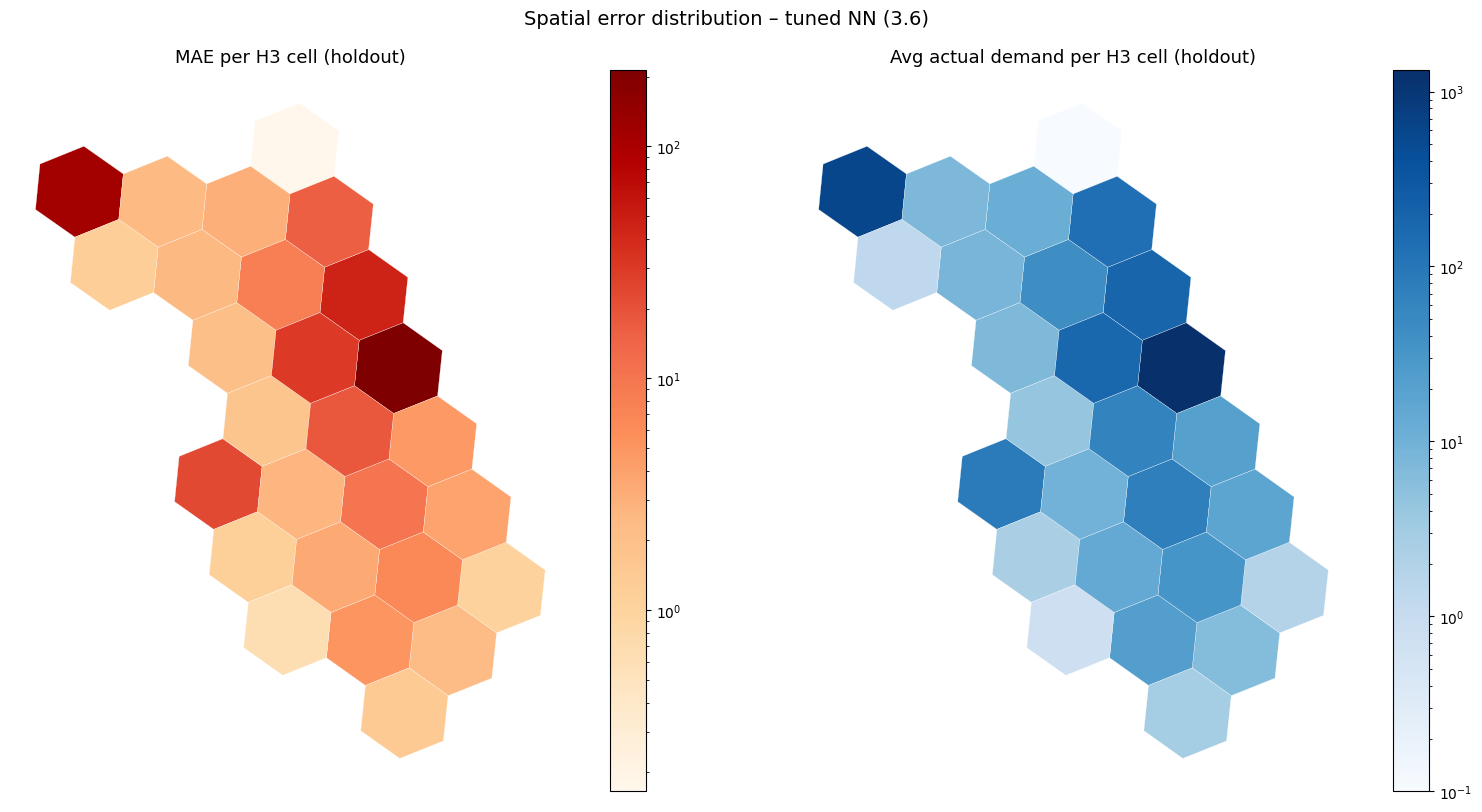

In [ ]:
import geopandas as gpd
from matplotlib.colors import LogNorm

gdf = gpd.GeoDataFrame(df_agg, geometry="geometry", crs="EPSG:4326")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# left: MAE per cell
gdf.plot(
    column     = "MAE",
    cmap       = "OrRd",
    linewidth  = 0.2,
    edgecolor  = "white",
    legend     = True,
    norm       = LogNorm(vmin=gdf["MAE"].clip(lower=0.1).min(),
                         vmax=gdf["MAE"].max()),   # log scale handles the skew
    ax         = axes[0],
)
axes[0].set_title("MAE per H3 cell (holdout)", fontsize=13)
axes[0].set_axis_off()

# right: average actual demand per cell (context)
gdf.plot(
    column    = "avg_demand",
    cmap      = "Blues",
    linewidth = 0.2,
    edgecolor = "white",
    legend    = True,
    norm      = LogNorm(vmin=gdf["avg_demand"].clip(lower=0.1).min(),
                        vmax=gdf["avg_demand"].max()),
    ax        = axes[1],
)
axes[1].set_title("Avg actual demand per H3 cell (holdout)", fontsize=13)
axes[1].set_axis_off()

plt.suptitle("Spatial error distribution – tuned NN (3.6)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
import joblib
joblib.dump(nn_baseline_est, "../models/nn_baseline.pkl")
joblib.dump(best_est, "../models/nn_tuned.pkl")

['../models/nn_tuned.pkl']

### Takeaway from 3.6
The following variables are consumed by section 3.8:

| Variable | Content |
|---|---|
| `best_est` | Fitted estimator (scaler + base PyTorch model + log1p wrapper) of tuned Neural Network model|
| `metrics_best` | `{"MAE": 19.3523, "RMSE": 69.9275, "R2": 0.9567}` on holdout |
| `y_pred_best` | Predicted demand in test dataset |

### 3.7 Resolution sensitivity

The two final models (best RBF-SVM from 3.4, tuned NN from 3.6) were selected on a single spatial-temporal resolution, H3 r6 x 4h. This section asks how far that choice drives the result, and which resolution actually serves the operational question best. Required outputs:

- both models re-evaluated across **spatial** resolutions (H3 r5 coarser, r6, r7 finer; Community Area) at fixed 4h bins;
- the explicit **census-tract** case the assignment asks for (3.7b);
- both models re-evaluated across **temporal** resolutions (1h, 4h, 8h, 1d) at fixed H3 r6;
- a combined table and a granularity-sparsity visualisation, ending in a recommended resolution for the client.

**Two methodological points before any numbers.**

*Raw error metrics are not comparable across resolutions.* Coarser cells aggregate more trips, so their `demand_count` (and therefore MAE and RMSE) is mechanically larger. An MAE of 30 at r6 and 8 at r7 does not mean r7 is "better", it means an r7 cell simply holds fewer trips. The cross-resolution comparison is therefore read on two scale-free quantities: **R^2** (variance explained, unit-free) and a **normalised MAE** (`nMAE = MAE / mean demand`). Raw MAE/RMSE are retained only for the within-resolution model-vs-model comparison.

*Resolution is varied, hyperparameters are not.* Re-tuning C/gamma and the network architecture at every resolution would confound the resolution effect with a tuning effect, besides being computationally infeasible. The configurations found in 3.4 and 3.6 are reused unchanged and only re-fitted on each resolution's training split. The hotspot anchors and the scaler are re-fitted per resolution (they are data-derived), exactly as in 3.2.

**Re-aggregation harness.** Each resolution needs its own demand panel, built from the trip-level data with the same aggregate + zero-fill + weather-merge logic as Task 1, so the schema matches `df_agg_r6_4h` exactly. `build_panel_at_resolution` returns the panel and a matching `centroid_fn` - the H3 cell centre for hexagons, and the empirical mean of pickup centroids for Community Area / Census Tract, so no external GeoJSON is required. `run_at_resolution` then reuses the 3.2 protocol end to end: grouped day-holdout, anchors on train only, shared scaler + log1p target, shared `evaluate`.

One cosmetic caveat: `build_features` (3.1) hard-codes the weather column names with a `_4h` suffix. The harness therefore emits the weather columns under those same names at every temporal resolution, so the values are correct but the suffix is not literal below 4h. Generalising the names would mean editing the shared 3.1 code, which is deliberately left untouched.

**Reliability caveat.** Each resolution refits the models once - the RBF-SVM on a day-subsample, the NN as a single fit of the tuned architecture rather than the CV-selected champion. The per-resolution numbers are therefore *indicative for the resolution trade-off, not a definitive model ranking*: a single NN refit can land 5-10 MAE above its tuned self, so where the two models look close here the authoritative head-to-head is the canonical comparison in 3.8a.

In [14]:
import time
import joblib

# trip-level dependency (see note above) 
TRIPS_PATH = PROCESSED / "df_trips_full.parquet"
TRIPS_COLS = ["trip_id", "trip_start_timestamp", "trip_miles", "trip_seconds", "trip_total",
              "h3_r5", "h3_r6", "h3_r7", "pickup_community_area", "pickup_census_tract",
              "pickup_centroid_latitude", "pickup_centroid_longitude"]
assert TRIPS_PATH.exists(), (
    f"{TRIPS_PATH} not found. Export trip-level data from Task 1 step 7 with columns "
    f"{TRIPS_COLS} before running 3.7.")
trips = pd.read_parquet(TRIPS_PATH, columns=TRIPS_COLS)

# hourly weather is saved by Task 1; aggregate it to any target frequency on the fly
weather_hourly = pd.read_parquet(PROCESSED / "df_weather_hours.parquet")

FREQ = {"time_1h": "h", "time_4h": "4h", "time_8h": "8h", "time_1d": "D"}


def _weather_at(freq, weather_hourly):
    """Aggregate hourly weather to `freq`, named exactly as build_features (3.1) expects."""
    w = weather_hourly.copy()
    w["timestamp"] = w["timestamp_h"].dt.floor(freq)
    return (w.groupby("timestamp")
             .agg(temp_4h=("temp_h", "mean"), rain_4h=("rain_h", "sum"),
                  snow_4h=("snow_h", "sum"), precip_4h=("precip_h", "sum"),
                  wind_speed_4h=("wind_speed_h", "mean"),
                  weather_code_4h=("weather_code_h", "max"))
             .reset_index())


def build_panel_at_resolution(trips, spatial_col, time_col, weather_hourly):
    """Trip-level -> (spatial_col x time bucket) demand panel, zero-filled, weather-merged.
    Mirrors Task 1's aggregate_demand + fill_zeros + weather merge. Returns (panel, centroid_fn)."""
    freq = FREQ[time_col]
    t = trips.dropna(subset=[spatial_col]).copy()
    t["timestamp"] = t["trip_start_timestamp"].dt.floor(freq)

    demand = (t.groupby([spatial_col, "timestamp"], observed=True)
                .agg(demand_count=("trip_id", "count"))
                .reset_index()
                .rename(columns={spatial_col: "location_id"}))

    # explicit zeros over the full (location x time) grid, as in Task 1's fill_zeros
    locs = demand["location_id"].unique()
    times = pd.date_range(demand["timestamp"].min(), demand["timestamp"].max(), freq=freq)
    grid = (pd.MultiIndex.from_product([locs, times], names=["location_id", "timestamp"])
              .to_frame(index=False))
    panel = grid.merge(demand, on=["location_id", "timestamp"], how="left")
    panel["demand_count"] = panel["demand_count"].fillna(0).astype("int64")
    panel = panel.merge(_weather_at(freq, weather_hourly), on="timestamp", how="left")

    # centroid function matching the spatial id type (cell 50 note)
    if spatial_col.startswith("h3_"):
        centroid_fn = _h3_centroids
    else:
        lut = (t.groupby(spatial_col, observed=True)
                 [["pickup_centroid_latitude", "pickup_centroid_longitude"]].mean())

        def centroid_fn(ids, _lut=lut):
            # location_id is a `category` dtype: .map on a categorical Series iterates ALL
            # categories — incl. census tracts with zero trips that are absent from _lut
            # (built with observed=True) -> KeyError. Cast to object so .map sees only the
            # values actually present, while preserving the index for build_features.
            ids = pd.Series(ids).astype(object)
            lat = ids.map(lambda c: _lut.loc[c, "pickup_centroid_latitude"]).astype("float64")
            lon = ids.map(lambda c: _lut.loc[c, "pickup_centroid_longitude"]).astype("float64")
            return lat, lon
    return panel, centroid_fn


# reuse the tuned configurations from 3.4 / 3.6 (read straight off the saved models)
_svr = joblib.load("../models/svm_rbf_best.pkl").regressor_.named_steps["model"]
SVM_PARAMS = {"C": _svr.C, "gamma": _svr.gamma, "epsilon": _svr.epsilon}
_nn = joblib.load("../models/nn_tuned.pkl").regressor_.named_steps["model"]
NN_PARAMS = {k: getattr(_nn, k) for k in
             ["hidden_sizes", "dropout", "lr", "batch_size", "max_epochs", "patience", "val_fraction"]}
print("reused SVM params:", SVM_PARAMS)
print("reused NN  params:", NN_PARAMS)

MAX_TRAIN_ROWS = 30_000   # fixed SVM/NN training budget across all resolutions (fair + tractable)

def _capped_train_index(y, max_rows, rng, n_strata=10):
    """Stratified row cap: split y into equal-size demand strata (by rank, robust to
    the many zeros) and draw equally from each, so high-demand hotspot buckets stay
    represented instead of being drowned out by the zero-demand majority."""
    n = len(y)
    if n <= max_rows:
        return np.arange(n)
    strata = pd.qcut(y.rank(method="first"), q=n_strata, labels=False)
    per = max_rows // n_strata
    idx = []
    for b in range(n_strata):
        pool = np.where(strata == b)[0]
        idx.append(rng.choice(pool, size=min(per, len(pool)), replace=False))
    return np.concatenate(idx)

def run_at_resolution(trips, spatial_col, time_col, weather_hourly, n_candidates=8):
    """Full 3.2 protocol at one (spatial, temporal) resolution. Returns a 2-row metrics frame."""
    from sklearn.model_selection import GroupShuffleSplit
    from sklearn.svm import SVR

    panel, centroid_fn = build_panel_at_resolution(trips, spatial_col, time_col, weather_hourly)
    panel["day"] = panel["timestamp"].dt.floor("D")

    gss = GroupShuffleSplit(n_splits=1, test_size=TEST_FRACTION, random_state=RANDOM_STATE)
    dev_i, test_i = next(gss.split(panel, groups=panel["day"]))
    dev, test = panel.iloc[dev_i].copy(), panel.iloc[test_i].copy()

    anchors = detect_hotspot_anchors(dev, centroid_fn=centroid_fn, n_candidates=n_candidates)
    Xd, yd, _ = build_features(dev,  anchors, centroid_fn=centroid_fn)
    Xt, yt, _ = build_features(test, anchors, centroid_fn=centroid_fn)

    # fixed stratified training budget so resolutions are compared at EQUAL data volume
    # (else finer grids unfairly get 20x more rows) and the RBF-SVM stays tractable
    rng = np.random.default_rng(RANDOM_STATE)
    idx = _capped_train_index(yd.reset_index(drop=True), MAX_TRAIN_ROWS, rng)
    Xd_fit, yd_fit = Xd.iloc[idx], yd.iloc[idx]

    svm = make_estimator(SVR(kernel="rbf", cache_size=1000, **SVM_PARAMS))
    svm.fit(Xd_fit, yd_fit)
    nn = make_estimator(PytorchRegressor(random_state=RANDOM_STATE, **NN_PARAMS))
    nn.fit(Xd_fit, yd_fit)

    mean_d = float(yt.mean())
    zero_rate = float((panel["demand_count"] == 0).mean())
    rows = []
    for name, est in [("RBF SVM", svm), ("Tuned NN", nn)]:
        mt = evaluate(yt, est.predict(Xt))
        rows.append({"spatial": spatial_col, "temporal": time_col, "model": name,
                     "n_cells": int(panel["location_id"].nunique()), "zero_rate": zero_rate,
                     "mean_demand": mean_d, "MAE": mt["MAE"], "nMAE": mt["MAE"] / mean_d,
                     "RMSE": mt["RMSE"], "R2": mt["R2"]})
    return pd.DataFrame(rows)


reused SVM params: {'C': 10.0, 'gamma': 0.1, 'epsilon': 0.1}
reused NN  params: {'hidden_sizes': (128, 64, 32), 'dropout': 0.1, 'lr': 0.0003, 'batch_size': 256, 'max_epochs': 150, 'patience': 15, 'val_fraction': 0.1}


#### 3.7a Spatial sensitivity (temporal fixed at 4h)

Both models are re-fitted and evaluated at H3 r5, r6 and r7, and at Community Area, all at 4-hour bins. `n_candidates` for anchor detection is kept at the default 8 here; it is raised for the finer census-tract grid in 3.7b. The table reports raw MAE/RMSE (within-resolution model comparison) alongside the scale-free `nMAE` and `R2` (cross-resolution comparison).

In [15]:
spatial_results = pd.concat(
    [run_at_resolution(trips, sp, "time_4h", weather_hourly)
     for sp in ["h3_r5", "h3_r6", "h3_r7", "pickup_community_area"]],
    ignore_index=True,
)
spatial_results.round(3)

,spatial,temporal,model,n_cells,zero_rate,mean_demand,MAE,nMAE,RMSE,R2
0,h3_r5,time_4h,RBF SVM,8,0.010,356.676,62.077,0.174,149.005,0.937
1,h3_r5,time_4h,Tuned NN,8,0.010,356.676,61.391,0.172,139.062,0.945
2,h3_r6,time_4h,RBF SVM,27,0.126,105.682,26.144,0.247,99.349,0.913
3,h3_r6,time_4h,Tuned NN,27,0.126,105.682,21.051,0.199,77.970,0.946
4,h3_r7,time_4h,RBF SVM,128,0.492,22.292,15.792,0.708,79.403,0.449
5,h3_r7,time_4h,Tuned NN,128,0.492,22.292,8.810,0.395,42.321,0.843
6,pickup_community_area,time_4h,RBF SVM,77,0.173,37.040,17.285,0.467,78.056,0.702
7,pickup_community_area,time_4h,Tuned NN,77,0.173,37.040,10.497,0.283,44.611,0.903


*Reading.* The granularity-sparsity trade-off is clear: from r5 to r7 the cells grow 8 -> 27 -> 128, mean demand falls **357 -> 106 -> 22**, the zero-rate climbs **1% -> 13% -> 49%**, and `R2` weakens (RBF-SVM **0.94 -> 0.91 -> 0.33**; nMAE 0.18 -> 0.25 -> 0.74). Raw MAE *falls* (62 -> 26 -> 16) purely because the cells hold fewer trips, as flagged above. Community Area (77 cells, SVM `R2` 0.69) sits between r6 and r7 on the reliable SVM reading. Its NN figure (`R2` 0.92) is higher, but per the caveat below should not be read as a resolution ranking. **Caveat on the model columns:** the per-resolution NN is a single refit and here underperforms its tuned self (its r6 MAE of 21.81 vs the canonical figure in 3.8a), so do **not** read the SVM-vs-NN ranking from this table - take it from 3.8a. What this table shows reliably is the SVM's degradation and the sparsity trade-off.

#### 3.7b Census tract as spatial unit

The assignment explicitly asks how performance changes when only census tracts are used as spatial units. Section 1.3 found that `pickup_census_tract` is missing for **55.65%** of trips, so the project uses it nowhere else. It is run here once, as the assignment requires, with the coverage limitation made explicit.

**Should the suppressed tracts be scaled up?** A natural idea is to multiply observed tract demand by `1 / coverage` (about `1 / 0.45`) to recover "true" totals. This is valid only if the missingness is **random** - if the observed tracts were a representative sample of all tracts. They are not. Chicago suppresses the census tract precisely when a trip would be re-identifiable, i.e. when *few* trips occur in that tract during that period. Suppression is therefore conditioned on low demand: it is **missing-not-at-random** and correlated with the target itself. Two consequences follow:

1. The observed 45% over-represents busy tracts and busy hours. A flat `1 / 0.45` factor would inflate exactly the low-demand cells that were hidden, distorting the spatial distribution rather than restoring it.
2. The true coverage factor is not a constant 0.45 but varies by tract and time, so no single multiplier is correct.

We therefore **do not scale**. Census tract is reported as a coverage-limited sensitivity check only: the metrics describe the observable subset, absolute demand is understated, and the panel is not comparable in level to the H3/CA panels. This is consistent with the decision already taken in 1.3. (Had suppression been a fixed random sample - e.g. "every tract reports, but only 45% of rows are logged" - the count-based `1/coverage` rescaling the question hints at would in fact be unbiased; the mechanism here simply is not of that kind.)

In [ ]:
ct_coverage = trips["pickup_census_tract"].notna().mean()
print(f"Census-tract coverage: {ct_coverage:.1%} of trips carry a tract id "
      f"(=> absolute demand levels below are understated, not rescaled)")

# finer grid than CA/H3-r6 => raise the anchor candidate pool so secondary hotspots survive
ct_results = run_at_resolution(trips, "pickup_census_tract", "time_4h",
                               weather_hourly, n_candidates=15)
ct_results.round(3)


Census-tract coverage: 45.6% of trips carry a tract id (=> absolute demand levels below are understated, not rescaled)


,spatial,temporal,model,n_cells,zero_rate,mean_demand,MAE,nMAE,RMSE,R2
0,pickup_census_tract,time_4h,RBF SVM,607,0.947,2.106,2.038,0.968,21.037,0.079
1,pickup_census_tract,time_4h,Tuned NN,607,0.947,2.106,1.535,0.729,17.326,0.375


*Reading.* Census tract is the floor: **607 cells, 94.7% of buckets empty, mean demand 2.1**, and `R2` collapses to **0.08 (SVM) / 0.38 (NN)** - essentially no better than predicting the mean for the SVM, and still weak for the NN. Two effects compound and cannot be separated here. First, the grid is extremely fine, so sparsity alone depresses `R2`, as it already did at r7. Second, only **45.6%** of trips carry a tract and the missing ones are the low-demand ones, so even the observed demand is a biased, deflated picture. The conclusion for the client is that census tract is unsuitable as a primary unit, Not because the model is weak, but because the input is both too fine and structurally incomplete in a demand-correlated way.

#### 3.7c Temporal sensitivity (spatial fixed at H3 r6)

The spatial unit is held at r6 and the time bucket is widened from 1h to 4h, 8h and 1d. Because temporal aggregation is a smoothing operation, the qualitative demand shape is preserved while variance falls; the question is whether the finer 1h target is too sparse to model well and whether 8h/1d over-smooth away the operational signal.

In [ ]:
temporal_results = pd.concat(
    [run_at_resolution(trips, "h3_r6", tc, weather_hourly)
     for tc in ["time_1h", "time_4h", "time_8h", "time_1d"]],
    ignore_index=True,
)
temporal_results.round(3)

,spatial,temporal,model,n_cells,zero_rate,mean_demand,MAE,nMAE,RMSE,R2
0,h3_r6,time_1h,RBF SVM,27,0.268,26.424,7.876,0.298,28.822,0.888
1,h3_r6,time_1h,Tuned NN,27,0.268,26.424,6.598,0.250,23.340,0.927
2,h3_r6,time_4h,RBF SVM,27,0.126,105.696,26.432,0.250,100.433,0.911
3,h3_r6,time_4h,Tuned NN,27,0.126,105.696,21.810,0.206,80.674,0.942
4,h3_r6,time_8h,RBF SVM,27,0.078,211.392,46.269,0.219,174.723,0.926
5,h3_r6,time_8h,Tuned NN,27,0.078,211.392,38.193,0.181,138.284,0.954
6,h3_r6,time_1d,RBF SVM,27,0.040,634.177,122.432,0.193,413.329,0.938
7,h3_r6,time_1d,Tuned NN,27,0.040,634.177,103.228,0.163,341.921,0.958


*Reading.* From 1h to 1d the zero-rate falls **26.8% -> 12.6% -> 7.8% -> 4.0%** and `R2` rises (RBF-SVM **0.89 -> 0.91 -> 0.93 -> 0.94**) while raw MAE grows with the bigger counts. But high `R2` at 1d is not a free win: a one-day bucket cannot answer "how many cars at 8am vs 6pm", the tactical question the client actually has. 4h is the practical compromise already chosen in Task 1 - enough temporal grain for shift planning, sparse enough to stay learnable. As in 3.7a the single NN refit is handicapped, so the reliable takeaway here is the monotone smoothing, not the model order (see 3.8a). Temporal binning is a smoothing knob, whereas the spatial unit is a modelling decision - which is why the spatial sweep carries more weight.

#### 3.7d Granularity-sparsity trade-off and recommendation

All runs are stacked into one table and the trade-off is visualised on the scale-free axes: `R2` and `nMAE` against the per-resolution zero-rate. The recommended resolution is the finest one at which `R2` is still acceptable and `nMAE` has not yet run away - i.e. the point where added spatial/temporal detail stops paying for itself in predictability.

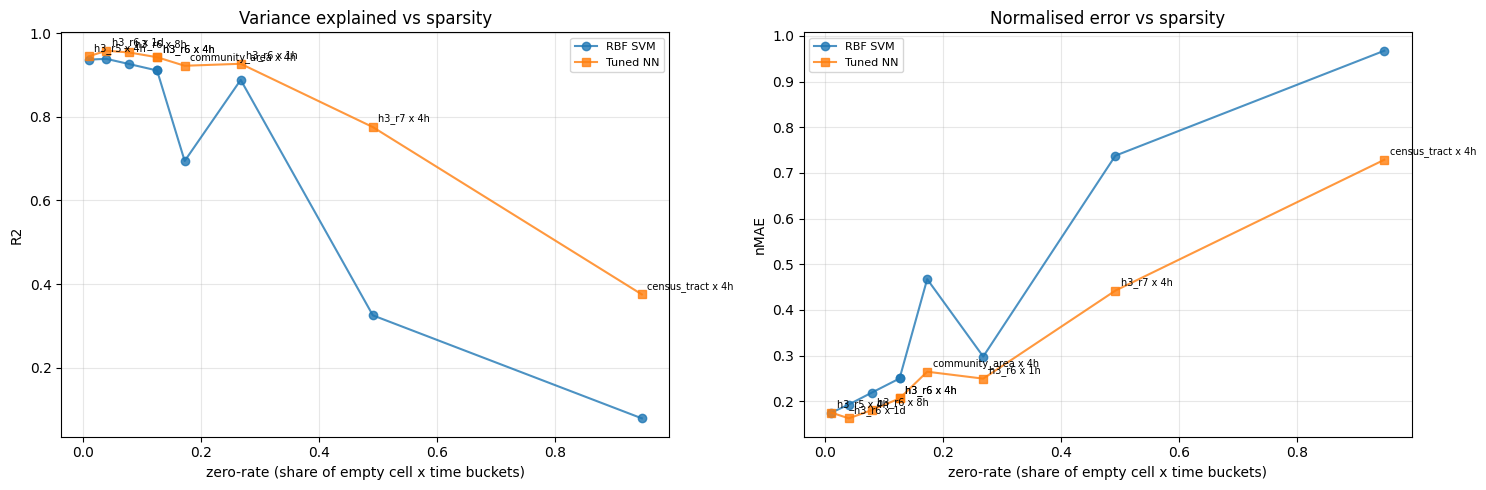

,resolution,model,n_cells,zero_rate,mean_demand,MAE,nMAE,RMSE,R2
0,h3_r5 x 4h,RBF SVM,8,0.010,356.725,62.534,0.175,149.828,0.937
1,h3_r5 x 4h,Tuned NN,8,0.010,356.725,62.518,0.175,140.144,0.945
2,h3_r6 x 4h,RBF SVM,27,0.126,105.696,26.432,0.250,100.433,0.911
3,h3_r6 x 4h,Tuned NN,27,0.126,105.696,21.810,0.206,80.674,0.942
4,h3_r7 x 4h,RBF SVM,128,0.492,22.295,16.451,0.738,87.854,0.325
5,h3_r7 x 4h,Tuned NN,128,0.492,22.295,9.864,0.442,50.704,0.775
6,community_area x 4h,RBF SVM,77,0.173,37.045,17.319,0.468,79.104,0.694
7,community_area x 4h,Tuned NN,77,0.173,37.045,9.812,0.265,39.986,0.922
8,census_tract x 4h,RBF SVM,607,0.947,2.106,2.038,0.968,21.037,0.079
9,census_tract x 4h,Tuned NN,607,0.947,2.106,1.535,0.729,17.326,0.375


In [ ]:
res_all = pd.concat([spatial_results, ct_results, temporal_results], ignore_index=True)
res_all["resolution"] = res_all["spatial"].str.replace("pickup_", "", regex=False) + " x " + \
                        res_all["temporal"].str.replace("time_", "", regex=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for model, mk in [("RBF SVM", "o"), ("Tuned NN", "s")]:
    sub = res_all[res_all["model"] == model].sort_values("zero_rate")
    axes[0].plot(sub["zero_rate"], sub["R2"], mk + "-", label=model, alpha=0.8)
    axes[1].plot(sub["zero_rate"], sub["nMAE"], mk + "-", label=model, alpha=0.8)
for ax, ycol, title in [(axes[0], "R2", "Variance explained vs sparsity"),
                        (axes[1], "nMAE", "Normalised error vs sparsity")]:
    for _, r in res_all[res_all["model"] == "Tuned NN"].iterrows():
        ax.annotate(r["resolution"], (r["zero_rate"], r[ycol]),
                    fontsize=7, xytext=(4, 4), textcoords="offset points")
    ax.set(xlabel="zero-rate (share of empty cell x time buckets)", ylabel=ycol, title=title)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

res_all[["resolution", "model", "n_cells", "zero_rate", "mean_demand",
         "MAE", "nMAE", "RMSE", "R2"]].round(3)


**Recommendation.** The sweep confirms **H3 r6 x 4h** as the operating point carried into the client recommendation. r5 has the highest `R2` (0.94) but only **8 cells**, which is operationally meaningless (no neighbourhood detail), its score is a coarse-grid artefact. r7 already pushes the zero-rate to 49% and collapses the SVM (`R2` 0.33). Census tract is the floor for the SVM (`R2` 0.08), though the NN still only reaches 0.38 there. r6 keeps `R2` around 0.9 with 27 cells and a ~14 mi^2 / 4-hour grain that matches how a fleet is dispatched (neighbourhood-level, shift-level). Community Area (SVM `R2` 0.69, NN `R2` 0.92) is the interpretable alternative for reporting. If a coarser, more reliably predictable unit were ever needed, r5 x 4h is the fallback.

### 3.8 Model comparison, shortfalls, and improvement levers

The two model families are compared on the common holdout from 3.2, at the identical H3 r6 x 4h resolution, so the numbers are directly comparable. Required outputs:

- a side-by-side holdout table (SVM vs NN) with MAE, RMSE, R^2 and cost;
- an explicit verdict on whether a deep-learning approach is warranted here;
- improvement levers for a follow-up project;
- a non-technical translation of the chosen model's error into a fleet-operations implication.

Sub-structure: **3.8a** the comparison table (plus a naive benchmark), **3.8b** the deep-learning verdict, **3.8c** improvement levers, **3.8d** the operational read-out.

#### 3.8a Holdout comparison

All four fitted estimators are loaded from `../models/` and scored on the untouched holdout `(X_test, y_test)` from 3.2. A **naive benchmark** is added: the historical mean demand per `(cell, time-of-day)` learned on the development set. It is not one of the two required models and it implicitly uses the target's own history (which both real models deliberately avoid as a feature) - it is included only as a reference floor, to show how much the models add over a trivial lookup. Inference time is measured directly, training cost is discussed in 3.8b (it differs by orders of magnitude across the families and is the crux of the verdict).

In [16]:
import time, joblib

models = {
    "Linear SVM":  joblib.load("../models/svm_linear_best.pkl"),
    "RBF SVM":     joblib.load("../models/svm_rbf_best.pkl"),
    "NN baseline": joblib.load("../models/nn_baseline.pkl"),
    "NN tuned":    joblib.load("../models/nn_tuned.pkl"),
}

rows = []
for name, est in models.items():
    t0 = time.perf_counter()
    pred = np.clip(est.predict(X_test), 0, None)
    infer_s = time.perf_counter() - t0
    rows.append({"model": name, **evaluate(y_test, pred), "infer_s": round(infer_s, 3)})

# naive benchmark: historical mean demand per (cell, hour-of-day), fitted on dev only
base_lut = (dev_panel.assign(h=dev_panel["timestamp"].dt.hour)
            .groupby(["location_id", "h"])["demand_count"].mean().to_dict())
gmean = float(dev_panel["demand_count"].mean())
keys = list(zip(test_panel["location_id"].values, test_panel["timestamp"].dt.hour.values))
pred_base = np.array([base_lut.get(k, gmean) for k in keys])
rows.append({"model": "Benchmark: hist. mean (cell x tod)",
             **evaluate(y_test, pred_base), "infer_s": np.nan})

comparison_3_8 = pd.DataFrame(rows).set_index("model").round(3)
comparison_3_8


,MAE,RMSE,R2,infer_s
model,,,,
Linear SVM,64.100,196.925,0.656,0.052
RBF SVM,30.838,118.910,0.875,30.052
NN baseline,26.750,91.346,0.926,0.007
NN tuned,19.352,69.925,0.957,0.013
Benchmark: hist. mean (cell x tod),29.135,107.124,0.898,NaN


#### 3.8b Is a deep-learning approach warranted?

On the canonical holdout (3.8a) the tuned NN is the best model (MAE **19.35**, R2 **0.957**), clearly ahead of the NN baseline (MAE 26.75, R2 0.926), so tuning improved holdout MAE substantially. Both NN variants clearly beat the RBF-SVM (MAE **30.8**, R2 0.875) and the linear SVM (MAE 64.10, R2 0.656). Three points decide the verdict:

- **The SVM does not beat the naive benchmark.** The historical-mean lookup scores MAE **29.1 / R2 0.898** which is *better* than the RBF-SVM on both metrics. Only the NN (MAE **19.35** / R2 **0.957**) adds real signal over a trivial baseline. A kernel SVM that, after a full grid search, fails to beat a lookup table is hard to justify as the deployed model.
- **Cost runs the same way.** The RBF-SVM had to be tuned on a day-subsample (kernel SVMs scale ~quadratically in samples) and takes **~29 s** to score the holdout, while the NN trains on the full development set and scores in **~0.01 s**, so roughly **2000x** faster inference. The deep model is both more accurate *and* cheaper to serve.
- **Interpretability** is not lost: SHAP (3.6) shows time-of-day and the hotspot distances dominate, which is enough for a client conversation.

**Verdict.** Deep learning is clearly worth it here: the NN is the only model that meaningfully beats the benchmark, and it is also the faster one to serve. The kernel SVM is neither, it underperforms a lookup table and is far slower. (The resolution sweep in 3.7 appeared to favour the SVM at coarse grids, but that is an artefact of the single NN refit used there, on the canonical models the NN leads (see the 3.7a caveat).)

#### 3.8c Improvement levers for a follow-up project

Ordered roughly by expected return on effort:

1. **Gradient-boosted trees (XGBoost / LightGBM).** On tabular spatio-temporal data these routinely match or beat both kernel SVMs and shallow feed-forward nets, train fast, and handle the heavy zero-inflation and skew natively. The strongest single next step and a fair third baseline.
2. **Point-of-interest features (OpenStreetMap).** Counts of bars, offices, transit stops, venues per cell would explain much of the residual spatial structure that bare centroid coordinates cannot - the assignment flags POI as a known strong driver of urban mobility.
3. **Richer temporal / event features.** Public holidays, large events (sports, concerts near the stadiums and the lakefront), school terms - these drive the demand spikes the current calendar features miss and that inflate RMSE.
4. **Finer / lagged weather.** Sub-hourly precipitation onset and a north/south station split (Task 1.5 noted the single-station simplification) could sharpen the weather response.
5. **Spatial embeddings.** Learned per-cell embeddings, or a graph/CNN over the H3 grid, would let the model share information between neighbouring cells beyond the three hand-picked anchor distances.
6. **More history.** Extending beyond the current window would stabilise the rare high-demand tail that both models currently under-predict (visible as the RMSE >> MAE gap).

#### 3.8d Operational interpretation (non-technical)

Translated for the client: at the chosen H3 r6 x 4h resolution, the best model predicts the number of pickups in a roughly 14 mi^2 neighbourhood over a 4-hour window with an average error of about 19 trips. In the dense core and at the airports, where a single bucket can hold hundreds of trips, that is a small relative miss and is good enough to plan how many vehicles to pre-position per shift. In quiet outer neighbourhoods, where a bucket holds only a handful of trips, the same 19-trip *average* error is dominated by a few hard-to-predict spikes (RMSE is far larger than MAE), so the model is reliable for *where the demand reliably is*, and weaker on rare surges at the edge.

For the fleet operator the practical message is twofold: (1) demand is predictable enough from calendar, weather and location alone, without ever looking at yesterday's demand, to support shift-level vehicle allocation in the high-demand zones, which is exactly where capital is committed first; and (2) the model should be used as a planning aid for the dense core, with a safety buffer rather than point predictions in the sparse periphery. This feeds directly into the strategic/tactical/operational recommendations consolidated in Section 5.

### Summary and hand-off

- **3.1-3.2 - foundation.** Target `demand_count` on the zero-filled H3 r6 x 4h panel, features = cyclical calendar + weekend flag, cell centroid coordinates, distances to the three demand anchors (downtown, O'Hare, Midway), and weather. Per-bucket trip aggregates and any same/past demand are excluded as leakage. Validation is a day-grouped 15% holdout with 5-fold GroupKFold for selection, a log1p target, and a shared `evaluate` on the original scale.
- **3.3-3.4 - SVM.** A linear SVR baseline (MAE ~66, R^2 ~0.63) is lifted by an RBF kernel with grid-searched C/gamma/epsilon to MAE **30.8** (R^2 0.875, RMSE 119).
- **3.5-3.6 - neural network.** A one-layer feed-forward baseline (MAE 26.8, R^2 0.93) is improved by tuning to a three-layer architecture reaching the best holdout error overall (MAE **19.35**, R^2 0.957). SHAP shows time-of-day and the hotspot distances as the dominant drivers.
- **3.7 - resolution.** Across H3 r5/r6/r7, Community Area, census tract and 1h/4h/8h/1d bins (compared on scale-free R^2 and nMAE), **H3 r6 x 4h** is the recommended operating point as finer grids and 1h bins are too zero-inflated (r7 `R2` 0.33, census tract SVM `R2` 0.08), daily bins lose the intra-day signal, census tract is also structurally incomplete and not rescalable.
- **3.8 - comparison.** The tuned NN (MAE **19.35**) is the only model that beats the naive benchmark (MAE 29.1) and is faster to serve than the RBF-SVM (MAE 30.8), which itself does not beat the benchmark. A deep-learning approach is therefore clearly warranted here.

These results inform the Discussion and Outlook in Section 5.